<a href="https://colab.research.google.com/github/amelyssaeu-ab/bio-dkm/blob/main/tarefa13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarefa 13: Aplicação de Distribuições de Probabilidade em Ciências Biológicas
**Integrantes do Grupo:** Drielly Mathias Albertti, Kawana Ganeo Carvalho, Melyssa Ponce Lopes.


---
## 1. Escolha da Base de Dados e Contexto Biológico

* **Base de dados:** *Iris Species Dataset* (UCI Machine Learning Repository / Fisher, 1936).
* **Instituição responsável:** UCI Machine Learning Repository.
* **Data de Acesso:** 07 de Outubro de 2026.
* **Significado de cada linha:** Representa as medições morfológicas de um único indivíduo (flor de *Iris*).
* **Unidade Experimental:** A flor (espécime individual).
* **Variáveis e Unidades:**
  - `sepal_length`: Comprimento da sépala (cm)
  - `sepal_width`: Largura da sépala (cm)
  - `petal_length`: Comprimento da pétala (cm)
  - `petal_width`: Largura da pétala (cm)
  - `species`: Espécie taxonômica (*Iris-setosa*, *Iris-versicolor*, *Iris-virginica*)
* **Tratamento de dados ausentes:** Não há valores ausentes no dataset (*Missing Attribute Values: None*).

### Pergunta Biológica Orientadora
*A variabilidade morfológica (comprimento e largura de pétalas e sépalas) diferencia significativamente os grupos taxonômicos do gênero Iris?*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# Configurações estéticas dos gráficos
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)

# Carregando a base de dados Iris diretamente da UCI ou dados locais
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
df = pd.read_csv(url, header=None, names=columns)

# Visualizando as primeiras linhas do dataset
print("Primeiras observações do Dataset Iris:")
display(df.head())

Primeiras observações do Dataset Iris:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 2.1 Distribuição Normal (Gaussiana)

### 1. Fórmula da Função Densidade de Probabilidade (PDF)
$$f(x) = \frac{1}{\sigma \sqrt{2\pi}} e^{-\frac{1}{2} \left(\frac{x - \mu}{\sigma}\right)^2}, \quad x \in \mathbb{R}$$

* **Símbolos:**
  * $x$: Valor individual da variável biológica contínua[cite: 1, 4].
  * $\mu$: Média populacional ($\mu \in \mathbb{R}$).
  * $\sigma$: Desvio-padrão populacional ($\sigma > 0$).
  * $\pi \approx 3.14159$, $e \approx 2.71828$.
* **Fonte Teórica:** Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica*. Saraiva.

### 2. Explicação Biológica vs. Estatística
Modelamos a medição **individual** da variável `petal_length` de *Iris-setosa* como uma variável aleatória contínua. Diferencia-se uma medida individual do organismo (uma única folha/pétala) da estatística amostral (como a média de 50 pétalas).

### 3. Parâmetros e Efeitos na Curva
* **$\mu$ (Localização):** Desloca o centro da curva ao longo do eixo X.
* **$\sigma$ (Escala/Dispersão):** Controla o "achatamento". $\sigma$ maior alarga a curva e reduz a altura do pico.

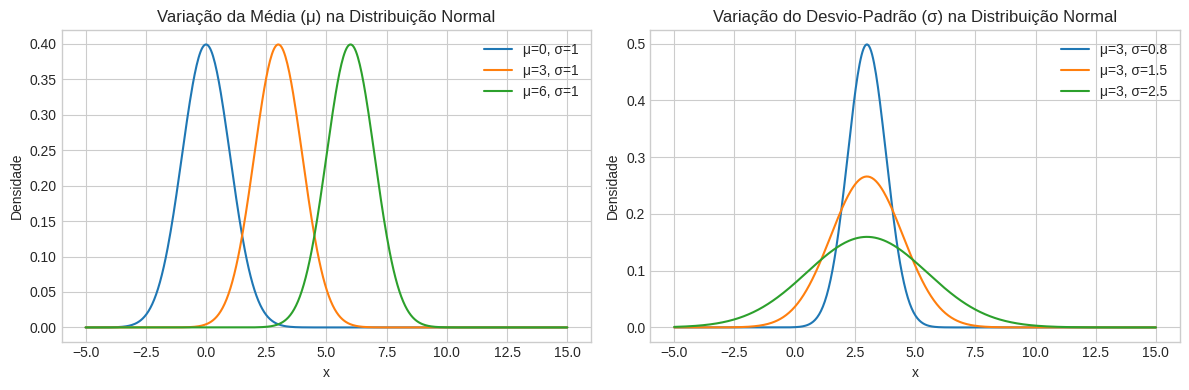

Setosa Petal Length - Média: 1.46 cm, Desvio-Padrão: 0.17 cm
P(X <= 1.3 cm) = 0.1723
P(1.3 cm <= X <= 1.6 cm) = 0.6111
P(X > 1.6 cm) = 0.2166
95% das pétalas de Iris-setosa têm comprimento menor ou igual a: 1.75 cm


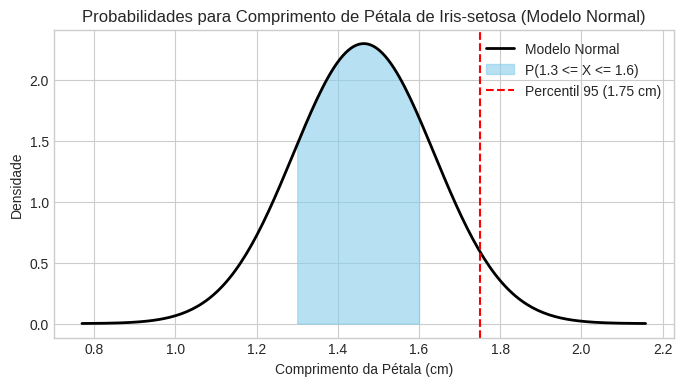

In [2]:
# --- PARTE A: Sensibilidade dos Parâmetros ---
x = np.linspace(-5, 15, 500)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for mu in [0, 3, 6]:
    plt.plot(x, stats.norm.pdf(x, loc=mu, scale=1), label=f'μ={mu}, σ=1')
plt.title('Variação da Média (μ) na Distribuição Normal')
plt.xlabel('x'); plt.ylabel('Densidade'); plt.legend()

plt.subplot(1, 2, 2)
for sigma in [0.8, 1.5, 2.5]:
    plt.plot(x, stats.norm.pdf(x, loc=3, scale=sigma), label=f'μ=3, σ={sigma}')
plt.title('Variação do Desvio-Padrão (σ) na Distribuição Normal')
plt.xlabel('x'); plt.ylabel('Densidade'); plt.legend()
plt.tight_layout()
plt.show()

# --- PARTE B: Aplicação nos dados de Iris-setosa ---
setosa_petal_len = df[df['species'] == 'Iris-setosa']['petal_length']
mu_hat = setosa_petal_len.mean()
sigma_hat = setosa_petal_len.std()

# Cálculo das probabilidades sob o modelo Normal assumido
p_acumulada = stats.norm.cdf(1.3, loc=mu_hat, scale=sigma_hat) # P(X <= 1.3)
p_entre = stats.norm.cdf(1.6, loc=mu_hat, scale=sigma_hat) - stats.norm.cdf(1.3, loc=mu_hat, scale=sigma_hat) # P(1.3 <= X <= 1.6)
p_acima = stats.norm.sf(1.6, loc=mu_hat, scale=sigma_hat) # P(X > 1.6)
p95 = stats.norm.ppf(0.95, loc=mu_hat, scale=sigma_hat) # Percentil 95

print(f"Setosa Petal Length - Média: {mu_hat:.2f} cm, Desvio-Padrão: {sigma_hat:.2f} cm")
print(f"P(X <= 1.3 cm) = {p_acumulada:.4f}")
print(f"P(1.3 cm <= X <= 1.6 cm) = {p_entre:.4f}")
print(f"P(X > 1.6 cm) = {p_acima:.4f}")
print(f"95% das pétalas de Iris-setosa têm comprimento menor ou igual a: {p95:.2f} cm")

# Gráfico com área sombreada
x_norm = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 200)
y_norm = stats.norm.pdf(x_norm, loc=mu_hat, scale=sigma_hat)

plt.figure(figsize=(8, 4))
plt.plot(x_norm, y_norm, 'k-', lw=2, label='Modelo Normal')
x_shade = np.linspace(1.3, 1.6, 100)
plt.fill_between(x_shade, stats.norm.pdf(x_shade, loc=mu_hat, scale=sigma_hat), color='skyblue', alpha=0.6, label='P(1.3 <= X <= 1.6)')
plt.axvline(p95, color='red', linestyle='--', label=f'Percentil 95 ({p95:.2f} cm)')
plt.title('Probabilidades para Comprimento de Pétala de Iris-setosa (Modelo Normal)')
plt.xlabel('Comprimento da Pétala (cm)'); plt.ylabel('Densidade'); plt.legend()
plt.show()

## 2.2 Distribuição t de Student

### 1. Fórmula da Função Densidade de Probabilidade (PDF)
$$f(t) = \frac{\Gamma\left(\frac{\nu + 1}{2}\right)}{\sqrt{\nu \pi} \, \Gamma\left(\frac{\nu}{2}\right)} \left(1 + \frac{t^2}{\nu}\right)^{-\frac{\nu + 1}{2}}, \quad t \in \mathbb{R}$$

* **Símbolos:**
  * $t$: Estatística padronizada do teste $t = \frac{\bar{X} - \mu_0}{S / \sqrt{n}}$.
  * $\nu$: Graus de liberdade ($\nu = n - 1$, onde $n$ é o tamanho da amostra).
  * $\Gamma$: Função Gama.
* **Fonte Teórica:** Morettin, P. A., & Bussab, W. O. (2017). *Estatística Básica*.

### 2. Explicação Biológica vs. Estatística
A distribuição $t$ **não** modela a folha/pétala diretamente, mas sim a **estatística da média amostral padronizada** quando o desvio-padrão populacional ($\sigma$) é desconhecido e estimado por $S$.

### 3. Parâmetros
* **$\nu$ (Graus de Liberdade):** Controla o peso das caudas. Quanto menor $\nu$, mais "pesadas" são as caudas (maior incerteza). Quando $\nu \to \infty$, a distribuição $t$ converge para a Normal Padrão $Z$.

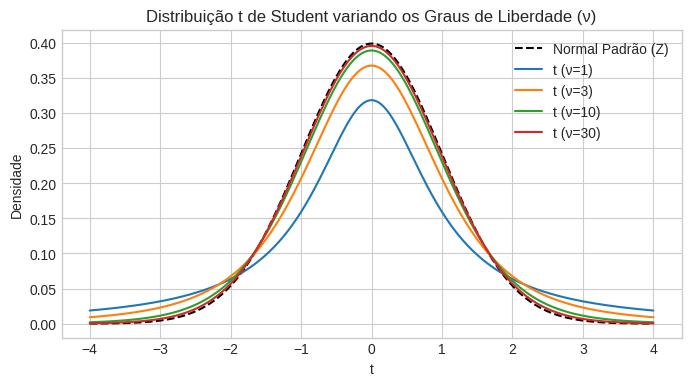

Estatística t observada: -0.8767 (com ν = 49)
P(T <= t_obs) = 0.1925
P(-1.0 <= T <= 1.0) = 0.6778
P(T > |t_obs|) [cauda superior] = 0.1925
Valor crítico t para 95% de confiança (bilateral): ±2.0096


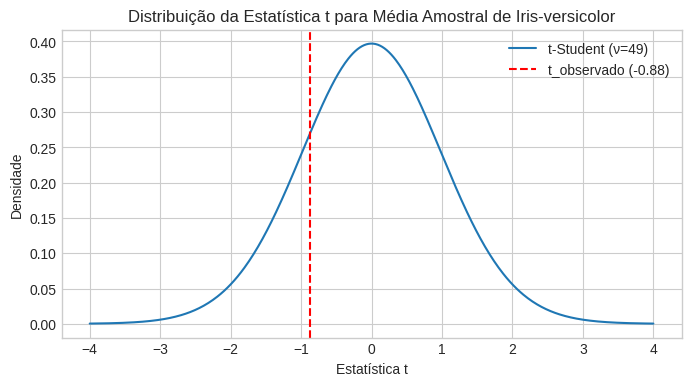

In [3]:
# --- PARTE A: Sensibilidade aos Graus de Liberdade ---
t_x = np.linspace(-4, 4, 500)
plt.figure(figsize=(8, 4))
plt.plot(t_x, stats.norm.pdf(t_x), 'k--', label='Normal Padrão (Z)')
for df_val in [1, 3, 10, 30]:
    plt.plot(t_x, stats.t.pdf(t_x, df=df_val), label=f't (ν={df_val})')
plt.title('Distribuição t de Student variando os Graus de Liberdade (ν)')
plt.xlabel('t'); plt.ylabel('Densidade'); plt.legend()
plt.show()

# --- PARTE B: Aplicação Prática no Dataset (Estatística Amostral) ---
# Pergunta: Testar se a média do comprimento de sépala da Iris-versicolor é diferente de 6.0 cm
sample_versicolor = df[df['species'] == 'Iris-versicolor']['sepal_length']
n = len(sample_versicolor)
nu = n - 1
mu_null = 6.0
x_bar = sample_versicolor.mean()
s = sample_versicolor.std(ddof=1)
t_obs = (x_bar - mu_null) / (s / np.sqrt(n))

p_tail_above = stats.t.sf(np.abs(t_obs), df=nu)
p_between = stats.t.cdf(1.0, df=nu) - stats.t.cdf(-1.0, df=nu)
p_cum = stats.t.cdf(t_obs, df=nu)
t_crit = stats.t.ppf(0.975, df=nu)

print(f"Estatística t observada: {t_obs:.4f} (com ν = {nu})")
print(f"P(T <= t_obs) = {p_cum:.4f}")
print(f"P(-1.0 <= T <= 1.0) = {p_between:.4f}")
print(f"P(T > |t_obs|) [cauda superior] = {p_tail_above:.4f}")
print(f"Valor crítico t para 95% de confiança (bilateral): ±{t_crit:.4f}")

# Gráfico da Distribuição t
plt.figure(figsize=(8, 4))
plt.plot(t_x, stats.t.pdf(t_x, df=nu), label=f't-Student (ν={nu})')
plt.axvline(t_obs, color='red', linestyle='--', label=f't_observado ({t_obs:.2f})')
plt.title('Distribuição da Estatística t para Média Amostral de Iris-versicolor')
plt.xlabel('Estatística t'); plt.ylabel('Densidade'); plt.legend()
plt.show()

## 2.3 Distribuição Qui-Quadrado ($\chi^2$)

### 1. Fórmula da Função Densidade de Probabilidade (PDF)
$$f(x) = \frac{1}{2^{\frac{k}{2}} \Gamma\left(\frac{k}{2}\right)} x^{\frac{k}{2} - 1} e^{-\frac{x}{2}}, \quad x > 0$$

* **Símbolos:**
  * $x$: Valor da estatística $Q = \frac{(n-1)S^2}{\sigma^2}$.
  * $k$: Graus de liberdade ($k \in \mathbb{N}^+$).
  * $\Gamma$: Função Gama.
* **Fonte Teórica:** Triola, M. F. (2018). *Introdução à Estatística*. LTC.

### 2. Explicação Biológica vs. Estatística
A distribuição $\chi^2$ modela a **variância amostral** ($S^2$) associada a uma amostra de medições biológicas, sob a suposição de que a população de origem seja Normal. Ela não representa diretamente a medida de uma planta.

### 3. Parâmetros e Efeitos
* **$k$ (Graus de Liberdade):** Determina a assimetria da curva. Para valores baixos de $k$, a curva é fortemente assimétrica à direita. À medida que $k$ aumenta, a curva se aproxima de uma forma simétrica (Gaussiana).

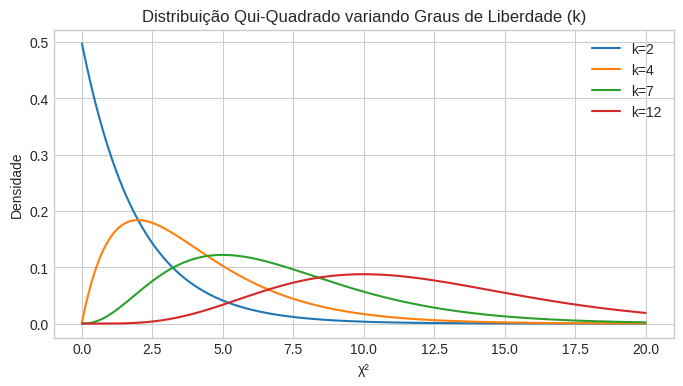

Estatística Q (Qui-Quadrado) observada: 49.1733 (k = 49)
P(Q <= q_obs) = 0.5338
P(40 <= Q <= 60) = 0.6819
P(Q > q_obs) = 0.4662
Percentil 95 de Q: 66.34


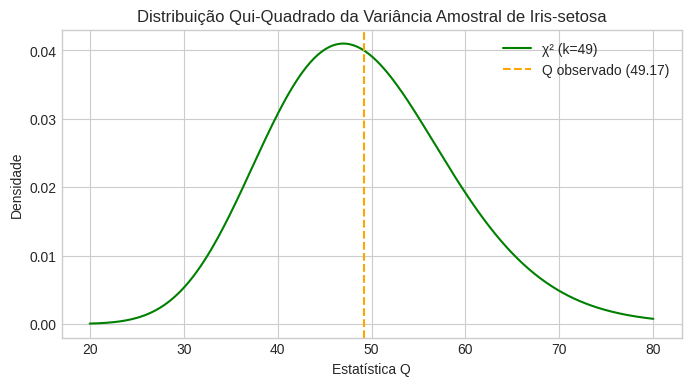

In [4]:
# --- PARTE A: Sensibilidade do Parâmetro k ---
chi_x = np.linspace(0.01, 20, 500)
plt.figure(figsize=(8, 4))
for k in [2, 4, 7, 12]:
    plt.plot(chi_x, stats.chi2.pdf(chi_x, df=k), label=f'k={k}')
plt.title('Distribuição Qui-Quadrado variando Graus de Liberdade (k)')
plt.xlabel('χ²'); plt.ylabel('Densidade'); plt.legend()
plt.show()

# --- PARTE B: Aplicação na Variabilidade de Iris-setosa ---
# Modelando a estatística Q = (n-1)*S^2 / sigma_0^2
n_setosa = len(setosa_petal_len)
k_df = n_setosa - 1
s2_obs = setosa_petal_len.var(ddof=1)
sigma2_0 = 0.03 # Hipótese para a variância populacional
q_obs = (k_df * s2_obs) / sigma2_0

p_chi_cum = stats.chi2.cdf(q_obs, df=k_df)
p_chi_between = stats.chi2.cdf(60, df=k_df) - stats.chi2.cdf(40, df=k_df)
p_chi_above = stats.chi2.sf(q_obs, df=k_df)
q95 = stats.chi2.ppf(0.95, df=k_df)

print(f"Estatística Q (Qui-Quadrado) observada: {q_obs:.4f} (k = {k_df})")
print(f"P(Q <= q_obs) = {p_chi_cum:.4f}")
print(f"P(40 <= Q <= 60) = {p_chi_between:.4f}")
print(f"P(Q > q_obs) = {p_chi_above:.4f}")
print(f"Percentil 95 de Q: {q95:.2f}")

# Gráfico Qui-Quadrado com sombreamento
plt.figure(figsize=(8, 4))
x_q = np.linspace(20, 80, 300)
plt.plot(x_q, stats.chi2.pdf(x_q, df=k_df), 'g-', label=f'χ² (k={k_df})')
plt.axvline(q_obs, color='orange', linestyle='--', label=f'Q observado ({q_obs:.2f})')
plt.title('Distribuição Qui-Quadrado da Variância Amostral de Iris-setosa')
plt.xlabel('Estatística Q'); plt.ylabel('Densidade'); plt.legend()
plt.show()

## 2.4 Distribuição F de Fisher-Snedecor

### 1. Fórmula da Função Densidade de Probabilidade (PDF)
$$f(x) = \frac{\sqrt{\frac{(d_1 x)^{d_1} d_2^{d_2}}{(d_1 x + d_2)^{d_1 + d_2}}}}{x \, \text{B}\left(\frac{d_1}{2}, \frac{d_2}{2}\right)}, \quad x > 0$$

* **Símbolos:**
  * $x$: Razão entre duas variâncias amostrais independentes $F = \frac{S_1^2}{S_2^2}$.
  * $d_1$: Graus de liberdade do numerador ($n_1 - 1$).
  * $d_2$: Graus de liberdade do denominador ($n_2 - 1$).
  * $\text{B}$: Função Beta.
* **Fonte Teórica:** Magalhães, M. N., & Lima, A. C. P. (2015). *Noções de Probabilidade e Estatística*. EDUSP.

### 2. Explicação Biológica vs. Estatística
A distribuição F **não** modela as medições individuais de uma espécie. Ela modela a **razão de duas variâncias amostrais** ($S_1^2 / S_2^2$). É utilizada para avaliar se a variabilidade de uma característica biológica em um grupo difere da variabilidade em outro grupo.

### 3. Parâmetros e Efeitos
* **$d_1$ e $d_2$:** Alteram o pico e o decaimento da cauda à direita. Ajustar $d_1$ altera a forma inicial da curva, enquanto $d_2$ tem maior controle sobre a dispersão e cauda da razão.

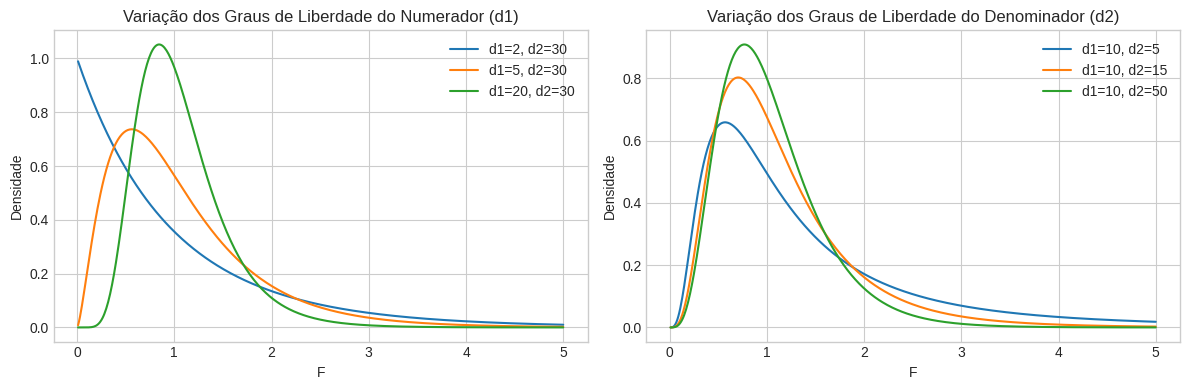

Variância Versicolor: 0.2664 | Variância Setosa: 0.1242
Estatística F observada (S_versicolor² / S_setosa²): 2.1443
P(F <= f_obs) = 0.9957
P(1.0 <= F <= 2.0) = 0.4916
P(F > f_obs) = 0.0043
Percentil 95 da distribuição F: 1.61


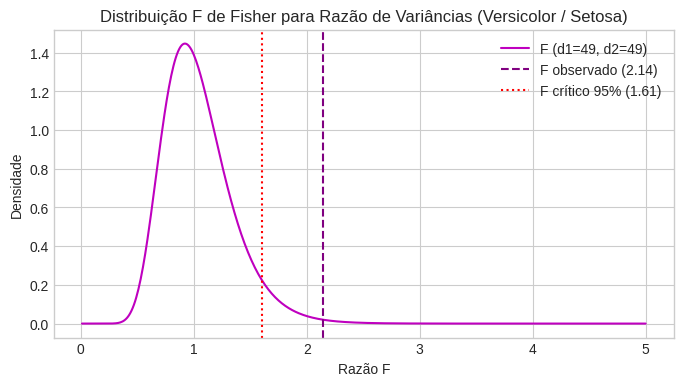

In [5]:
# --- PARTE A: Sensibilidade variando d1 e d2 separadamente ---
fx = np.linspace(0.01, 5, 500)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for d1 in [2, 5, 20]:
    plt.plot(fx, stats.f.pdf(fx, dfn=d1, dfd=30), label=f'd1={d1}, d2=30')
plt.title('Variação dos Graus de Liberdade do Numerador (d1)')
plt.xlabel('F'); plt.ylabel('Densidade'); plt.legend()

plt.subplot(1, 2, 2)
for d2 in [5, 15, 50]:
    plt.plot(fx, stats.f.pdf(fx, dfn=10, dfd=d2), label=f'd1=10, d2={d2}')
plt.title('Variação dos Graus de Liberdade do Denominador (d2)')
plt.xlabel('F'); plt.ylabel('Densidade'); plt.legend()
plt.tight_layout()
plt.show()

# --- PARTE B: Aplicação - Razão de Variâncias do Comprimento de Sépula ---
# Grupos: Iris-versicolor vs. Iris-setosa
var_versicolor = df[df['species'] == 'Iris-versicolor']['sepal_length'].var(ddof=1)
var_setosa = df[df['species'] == 'Iris-setosa']['sepal_length'].var(ddof=1)

d1_val = len(df[df['species'] == 'Iris-versicolor']) - 1
d2_val = len(df[df['species'] == 'Iris-setosa']) - 1

f_obs = var_versicolor / var_setosa # Razão de variâncias

p_f_cum = stats.f.cdf(f_obs, dfn=d1_val, dfd=d2_val)
p_f_between = stats.f.cdf(2.0, dfn=d1_val, dfd=d2_val) - stats.f.cdf(1.0, dfn=d1_val, dfd=d2_val)
p_f_above = stats.f.sf(f_obs, dfn=d1_val, dfd=d2_val)
f_95 = stats.f.ppf(0.95, dfn=d1_val, dfd=d2_val)

print(f"Variância Versicolor: {var_versicolor:.4f} | Variância Setosa: {var_setosa:.4f}")
print(f"Estatística F observada (S_versicolor² / S_setosa²): {f_obs:.4f}")
print(f"P(F <= f_obs) = {p_f_cum:.4f}")
print(f"P(1.0 <= F <= 2.0) = {p_f_between:.4f}")
print(f"P(F > f_obs) = {p_f_above:.4f}")
print(f"Percentil 95 da distribuição F: {f_95:.2f}")

# Gráfico da Razão F com sombreamento
plt.figure(figsize=(8, 4))
plt.plot(fx, stats.f.pdf(fx, dfn=d1_val, dfd=d2_val), 'm-', label=f'F (d1={d1_val}, d2={d2_val})')
plt.axvline(f_obs, color='purple', linestyle='--', label=f'F observado ({f_obs:.2f})')
plt.axvline(f_95, color='red', linestyle=':', label=f'F crítico 95% ({f_95:.2f})')
plt.title('Distribuição F de Fisher para Razão de Variâncias (Versicolor / Setosa)')
plt.xlabel('Razão F'); plt.ylabel('Densidade'); plt.legend()
plt.show()

## 3. Discussão das Condições e Limitações da Base Iris

1. **Diferença entre Medida Biológica e Estatística:**
   - A **Distribuição Normal** foi aplicada como aproximação paramétrica para a *medida direta do indivíduo* ($X$), assumindo continuabilidade[cite: 1, 4].
   - As distribuições **t**, **Qui-Quadrado** e **F** modelam *estatísticas calculadas a partir das amostras* (média padronizada, variância ponderada e razão de variâncias, respectivamente).

2. **Suposições das Distribuições Amostrais:**
   - As derivações de $t$, $\chi^2$ e $F$ exigem a **premissa de normalidade** das observações subjacentes e **independência** entre as amostras.
   - Embora o dataset Iris seja composto por observações independentes colhidas por Fisher (1936), generalizações para populações biológicas globais devem ser feitas com cautela devido ao escopo amostral reduzido ($n=50$ por espécie).

3. **Fontes Consultadas:**
   - Fisher, R. A. (1936). *The use of multiple measurements in taxonomic problems*. Annual Eugenics, 7, Part II, 179-188.
   - UCI Machine Learning Repository - Iris Dataset.
   - Documentação Oficial SciPy (`scipy.stats`).
   - Bussab, W. O., & Morettin, P. A. (2017). *Estatística Básica*.